# Assignment 4: Regularization

In [2]:
!git clone https://github.com/ds4e/undergrad_ml_assignments.git

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 126 (delta 0), reused 0 (delta 0), pack-reused 124 (from 2)
Receiving objects: 100% (126/126), 12.31 MiB | 20.33 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**Answer for Question 1:**

1) Adding a penalty discourages large coefficients, which helps prevent the model from overfitting the data. Instead of only minimizing error, the model is also encouraged to stay simple, leading to better generalization.

2) Regularization controls model complexity. A small penalty leads to low bias but high variance, while a large penalty increases bias but reduces variance. By adjusting the penalty, we can find a balance that minimizes overall prediction error.

3) Ridge regression shrinks coefficients toward zero but keeps all variables in the model. LASSO can shrink some coefficients exactly to zero, effectively performing feature selection. Ridge is better when many variables have small effects, while LASSO is useful when only a few variables are important.

4) We typically standardize variables so they have mean 0 and variance 1. This ensures that all features are penalized equally, since regularization depends on the size of the coefficients and would otherwise be affected by the scale of the variables.

5) The penalty is usually chosen using cross-validation by testing different values of α and selecting the one that gives the lowest validation error.

6) No, the penalty term is not included when evaluating cross-validated MSE. The goal is to measure prediction error on new data, and the penalty is only used during training to control model complexity.



**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [20]:
# 1
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./undergrad_ml_assignments/data/cars_hw.csv')

df["Age"] = 2026 - df["Make_Year"]

X = df[["Mileage_Run", "Age"]]
y = df["Price"]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [21]:
# 2
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_scaled, y)

coefs_lr = pd.Series(lr.coef_, index=feature_names)
print("Linear Regression Coefficients:\n")
print(coefs_lr)

interaction_coef = coefs_lr["Mileage_Run Age"]
print("\nInteraction coefficient:", interaction_coef)

Linear Regression Coefficients:

Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05
dtype: float64

Interaction coefficient: -1671212.3563918793


The interaction between Mileage_Run and Age is negative. This indicates that as both mileage and age increase, the price decreases more sharply, meaning older cars with higher mileage lose value faster.

In [22]:
# 3
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, y)

print("Optimal alpha:", lasso.alpha_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22977691506.578125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 598283106767.5625, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 850706961927.5469, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objec

Optimal alpha: 88.58667904100822


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 57665416569.234375, tolerance: 12772170136.099136
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 499617312683.5469, tolerance: 12772170136.099136
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 642246299479.5938, tolerance: 12772170136.099136
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergenc

Using 20-fold cross-validation, the optimal penalty parameter is α ≈ 88.59, which minimizes the cross-validated mean squared error.

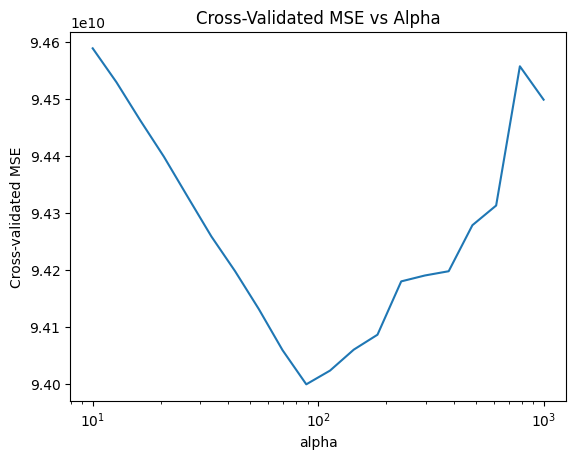

In [23]:
# 4
import matplotlib.pyplot as plt

mean_mse = np.mean(lasso.mse_path_, axis=1)

plt.figure()
plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Cross-Validated MSE vs Alpha")
plt.show()

The cross-validated MSE decreases as α increases initially, reaches a minimum around α ≈ 100, and then increases again. This reflects the bias–variance trade off, where moderate regularization provides the best predictive performance.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.410e+10, tolerance: 1.316e

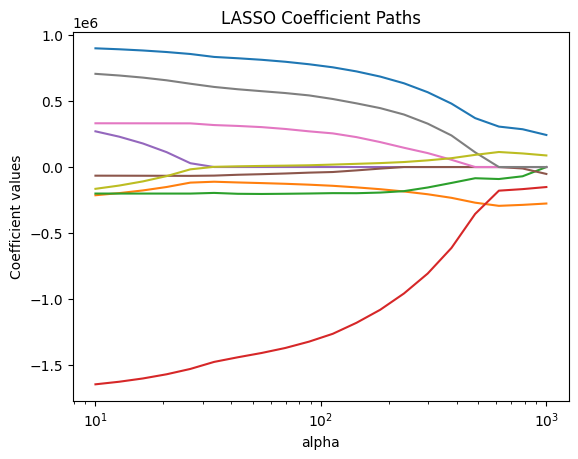

In [24]:
# 5
from sklearn.linear_model import Lasso

coefs_path = []

for a in alphas:
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X_scaled, y)
    coefs_path.append(l.coef_)

coefs_path = np.array(coefs_path)

plt.figure()
for i in range(coefs_path.shape[1]):
    plt.plot(alphas, coefs_path[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient values")
plt.title("LASSO Coefficient Paths")
plt.show()

As α increases, all coefficients shrink toward zero. Some coefficients approach zero faster than others, showing that LASSO selectively removes less important features while retaining the most influential ones.

In [26]:
# 6
coefs_lasso = pd.Series(lasso.coef_, index=feature_names)

print("LASSO Coefficients:\n")
print(coefs_lasso)

selected_features = coefs_lasso[coefs_lasso != 0]
print("\nSelected features:\n", selected_features)

num_zero = (coefs_lasso == 0).sum()
total = len(coefs_lasso)
print("\nProportion set to zero:", num_zero / total)

LASSO Coefficients:

Mileage_Run          7.789506e+05
Age                 -1.337436e+05
Mileage_Run^2       -2.006015e+05
Mileage_Run Age     -1.323307e+06
Age^2                0.000000e+00
Mileage_Run^3       -4.246012e+04
Mileage_Run^2 Age    2.705049e+05
Mileage_Run Age^2    5.428505e+05
Age^3                1.334198e+04
dtype: float64

Selected features:
 Mileage_Run          7.789506e+05
Age                 -1.337436e+05
Mileage_Run^2       -2.006015e+05
Mileage_Run Age     -1.323307e+06
Mileage_Run^3       -4.246012e+04
Mileage_Run^2 Age    2.705049e+05
Mileage_Run Age^2    5.428505e+05
Age^3                1.334198e+04
dtype: float64

Proportion set to zero: 0.1111111111111111


LASSO selects most features but sets Age^2 exactly to zero, effectively removing it from the model. Approximately 11.1% of the coefficients are set to zero, indicating some feature selection.

In [27]:
# 7
comparison = pd.DataFrame({
    "Linear Regression": coefs_lr,
    "LASSO": coefs_lasso
})

print("\nCoefficient Comparison:\n")
print(comparison)


Coefficient Comparison:

                   Linear Regression         LASSO
Mileage_Run             9.117748e+05  7.789506e+05
Age                    -2.481722e+05 -1.337436e+05
Mileage_Run^2          -2.072926e+05 -2.006015e+05
Mileage_Run Age        -1.671212e+06 -1.323307e+06
Age^2                   3.505507e+05  0.000000e+00
Mileage_Run^3          -6.514490e+04 -4.246012e+04
Mileage_Run^2 Age       3.388195e+05  2.705049e+05
Mileage_Run Age^2       7.167816e+05  5.428505e+05
Age^3                  -2.100379e+05  1.334198e+04


Compared to linear regression, LASSO shrinks the magnitude of most coefficients and sets some to zero, producing a simpler model. No coefficients increase in magnitude. However, the coefficient for Age^3 changes sign, indicating instability or multicollinearity among higher-order terms. Overall, LASSO improves interpretability by reducing model complexity.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [28]:
# 1
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./undergrad_ml_assignments/data/heart_failure_clinical_records_dataset.csv')

X_cont = df[['age', 'ejection_fraction', 'serum_creatinine']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_cont)

scaler_cont = StandardScaler()
X_poly_scaled = scaler_cont.fit_transform(X_poly)

X_cat = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]

poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_inter = poly_cat.fit_transform(X_cat)

scaler_cat = StandardScaler()
X_cat_inter_scaled = scaler_cat.fit_transform(X_cat_inter)

X_final = np.hstack([X_poly_scaled, X_cat_inter_scaled])

y = df['DEATH_EVENT']

In [29]:
# 2
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_final, y)

feature_names_cont = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
feature_names_cat = poly_cat.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])

feature_names = list(feature_names_cont) + list(feature_names_cat)

coefs_lr = pd.Series(lr.coef_, index=feature_names)
print(coefs_lr)

age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.072156
anaemia                        

Some of the coefficients have signs that don’t seem to make sense. For example, serum_creatinine is negative, even though higher values are usually linked to worse outcomes. The higher-order terms (like squared and cubic terms) also have inconsistent signs.

This happens because the model includes many related variables, like powers and interactions of the same features. These variables overlap in what they capture, so it becomes hard to interpret any single coefficient on its own. Instead, the true effect of a variable comes from looking at all its related terms together.

In [30]:
# 3
from sklearn.linear_model import LassoCV

alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso.fit(X_final, y)

print("Optimal alpha:", lasso.alpha_)

Optimal alpha: 0.005736152510448681


Using 20-fold cross-validation, the optimal penalty parameter is α ≈ 0.0057, which minimizes the cross-validated mean squared error.

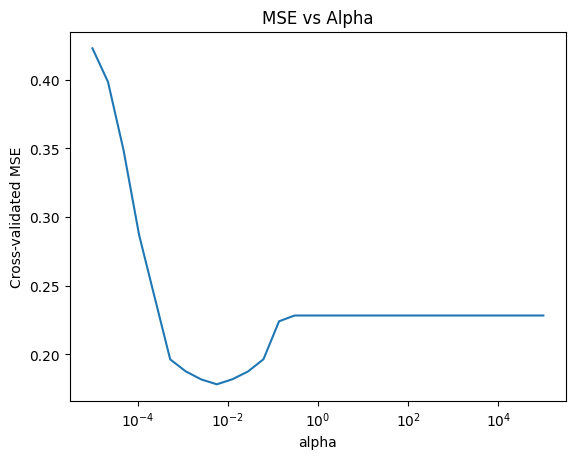

In [34]:
# 4
import matplotlib.pyplot as plt
import numpy as np

mean_mse = np.mean(lasso.mse_path_, axis=1)

plt.figure()
plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("MSE vs Alpha")
plt.show()

The cross-validated MSE decreases sharply for small values of α, reaches a minimum around α ≈ 10^-2, and then increases as α becomes larger. This reflects the bias–variance trade off, where moderate regularization improves performance, but excessive regularization leads to underfitting.

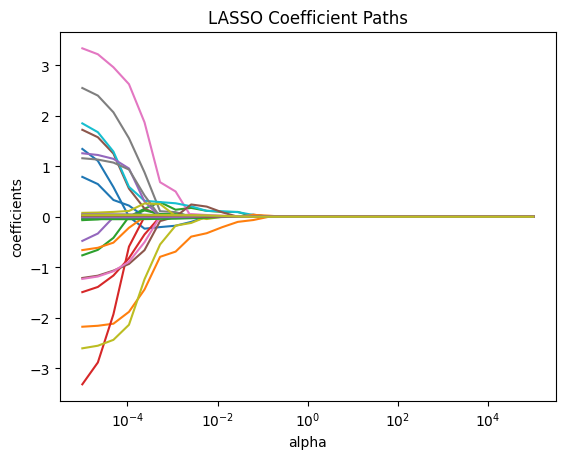

In [32]:
# 5
from sklearn.linear_model import Lasso

coefs_path = []

for a in alphas:
    l = Lasso(alpha=a, max_iter=100000)
    l.fit(X_final, y)
    coefs_path.append(l.coef_)

coefs_path = np.array(coefs_path)

plt.figure()
for i in range(coefs_path.shape[1]):
    plt.plot(alphas, coefs_path[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("LASSO Coefficient Paths")
plt.show()

As α increases, the coefficients shrink toward zero, with many becoming exactly zero. This demonstrates how LASSO performs feature selection by eliminating less important variables while retaining the most influential ones.

In [33]:
# 6
coefs_lasso = pd.Series(lasso.coef_, index=feature_names)

print("LASSO coefficients:\n")
print(coefs_lasso)

selected = coefs_lasso[coefs_lasso != 0]
print("\nSelected features:\n", selected)

num_zero = (coefs_lasso == 0).sum()
total = len(coefs_lasso)
print("\nProportion zero:", num_zero / total)

comparison = pd.DataFrame({
    "Linear": coefs_lr,
    "LASSO": coefs_lasso
})

print("\nComparison:\n")
print(comparison)

LASSO coefficients:

age                                      -0.000000
ejection_fraction                        -0.326124
serum_creatinine                          0.117426
age^2                                     0.000000
age ejection_fraction                    -0.000000
age serum_creatinine                      0.000000
ejection_fraction^2                       0.000000
ejection_fraction serum_creatinine        0.000000
serum_creatinine^2                       -0.000000
age^3                                     0.116214
age^2 ejection_fraction                   0.000000
age^2 serum_creatinine                    0.000000
age ejection_fraction^2                   0.000000
age ejection_fraction serum_creatinine    0.000000
age serum_creatinine^2                   -0.000000
ejection_fraction^3                       0.200750
ejection_fraction^2 serum_creatinine      0.034419
ejection_fraction serum_creatinine^2     -0.000000
serum_creatinine^3                       -0.045558
anaemia   

LASSO selects a relatively small subset of features and sets many coefficients to zero. Approximately 58.6% of the coefficients are set to zero, indicating substantial feature selection and model simplification.

Compared to linear regression, LASSO significantly shrinks coefficient magnitudes and removes many features. Some coefficients change sign, such as serum_creatinine, which switches from negative in the linear model to positive in LASSO. Additionally, several higher order and interaction terms are eliminated entirely.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?